In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
# Load data
df = pd.read_csv(r'C:\Users\pradh\OneDrive\Desktop\Telco-Customer-Churn.csv')

In [5]:
# Fix TotalCharges
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df.dropna(inplace=True)

In [6]:
print("Shape:", df.shape)
print("Churn Rate:")
print(df['Churn'].value_counts(normalize=True) * 100)

Shape: (7032, 21)
Churn Rate:
Churn
No     73.421502
Yes    26.578498
Name: proportion, dtype: float64


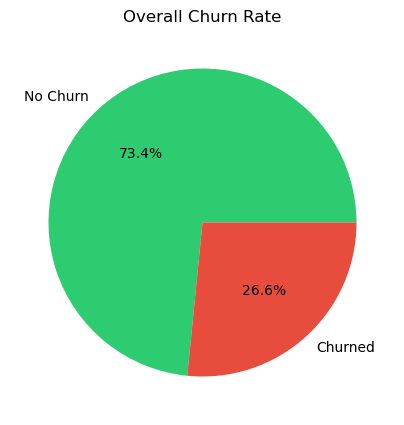

In [7]:
# ---- CHART 1: Overall Churn Rate ----
churn_counts = df['Churn'].value_counts()
plt.figure(figsize=(5,5))
plt.pie(churn_counts, labels=['No Churn','Churned'], 
        autopct='%1.1f%%', colors=['#2ecc71','#e74c3c'])
plt.title('Overall Churn Rate')
plt.savefig(r'C:\Users\pradh\OneDrive\Desktop\churn_rate.png')
plt.show()

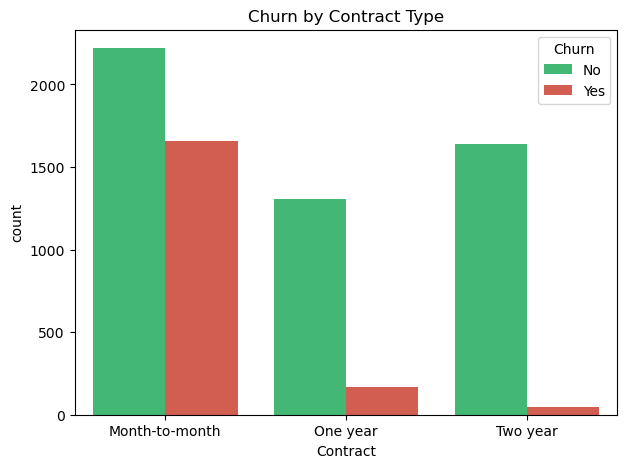

In [8]:
# ---- CHART 2: Churn by Contract Type ----
plt.figure(figsize=(7,5))
sns.countplot(x='Contract', hue='Churn', data=df,
              palette=['#2ecc71','#e74c3c'])
plt.title('Churn by Contract Type')
plt.savefig(r'C:\Users\pradh\OneDrive\Desktop\churn_contract.png')
plt.show()

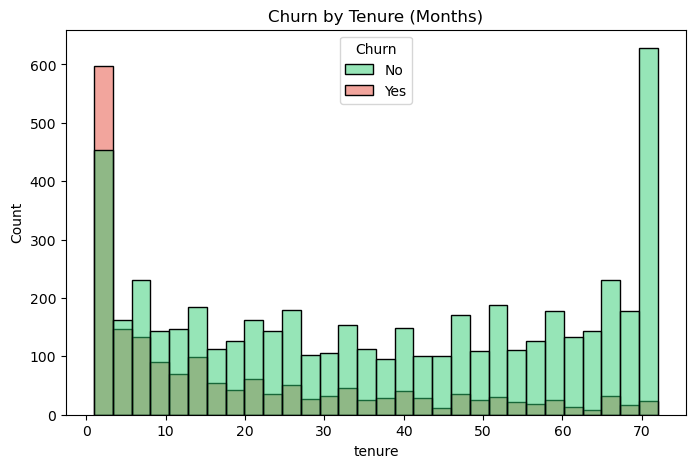

In [9]:
# ---- CHART 3: Churn by Tenure ----
plt.figure(figsize=(8,5))
sns.histplot(data=df, x='tenure', hue='Churn',
             bins=30, palette=['#2ecc71','#e74c3c'])
plt.title('Churn by Tenure (Months)')
plt.savefig(r'C:\Users\pradh\OneDrive\Desktop\churn_tenure.png')
plt.show()

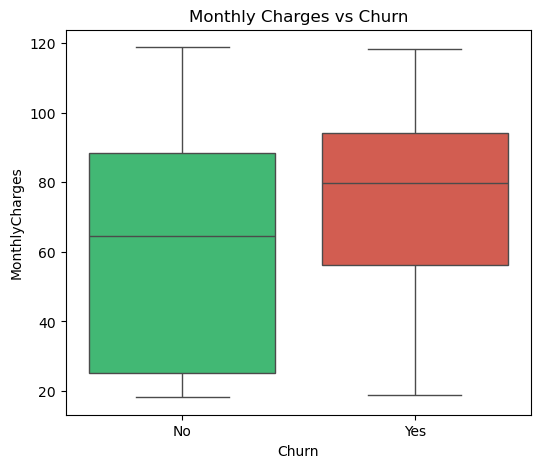

In [11]:
# ---- CHART 4: Monthly Charges vs Churn ----
plt.figure(figsize=(6,5))
sns.boxplot(x='Churn', y='MonthlyCharges', data=df,
            hue='Churn', palette=['#2ecc71','#e74c3c'], legend=False)
plt.title('Monthly Charges vs Churn')
plt.savefig(r'C:\Users\pradh\OneDrive\Desktop\churn_charges.png')
plt.show()

In [12]:
print("All 4 charts saved to Desktop!")

All 4 charts saved to Desktop!


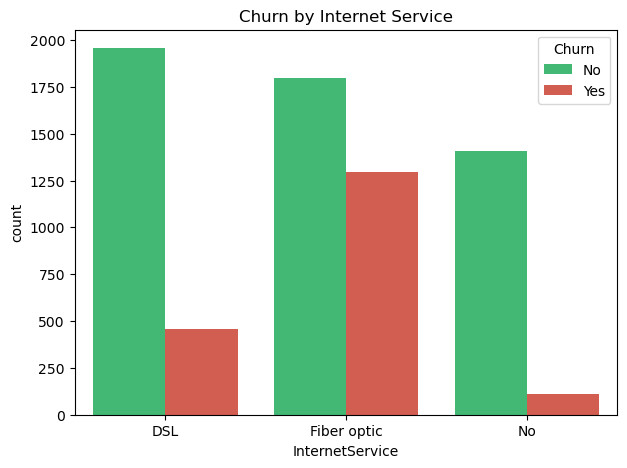

In [13]:
# ---- CHART 5: Churn by Internet Service ----
plt.figure(figsize=(7,5))
sns.countplot(x='InternetService', hue='Churn', data=df,
              palette=['#2ecc71','#e74c3c'])
plt.title('Churn by Internet Service')
plt.savefig(r'C:\Users\pradh\OneDrive\Desktop\churn_internet.png')
plt.show()

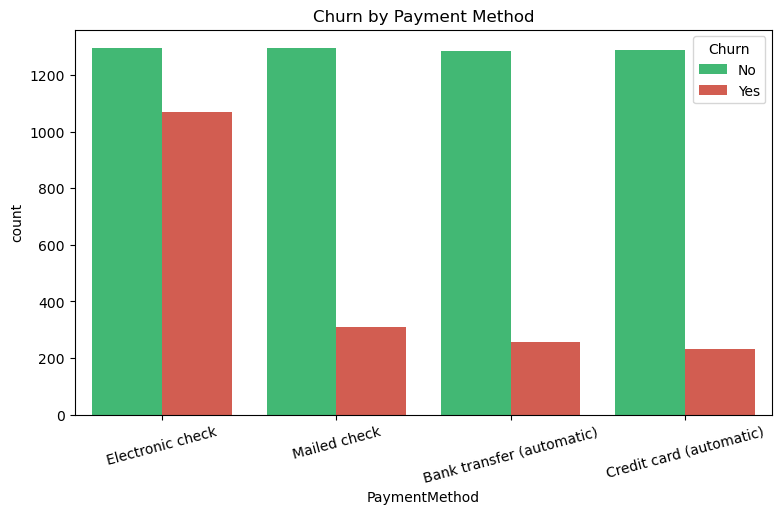

In [14]:
# ---- CHART 6: Churn by Payment Method ----
plt.figure(figsize=(9,5))
sns.countplot(x='PaymentMethod', hue='Churn', data=df,
              palette=['#2ecc71','#e74c3c'])
plt.xticks(rotation=15)
plt.title('Churn by Payment Method')
plt.savefig(r'C:\Users\pradh\OneDrive\Desktop\churn_payment.png')
plt.show()

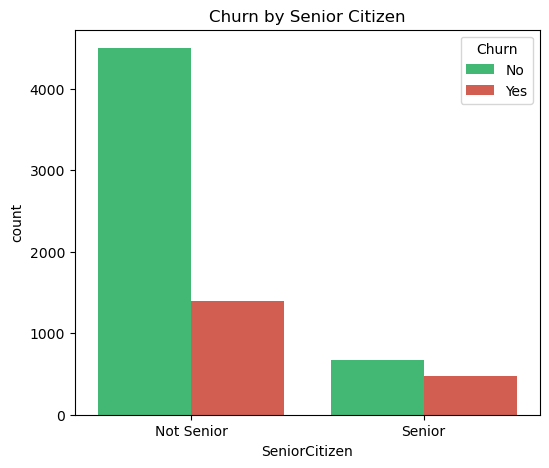

In [15]:
# ---- CHART 7: Churn by Senior Citizen ----
plt.figure(figsize=(6,5))
sns.countplot(x='SeniorCitizen', hue='Churn', data=df,
              palette=['#2ecc71','#e74c3c'])
plt.xticks([0,1], ['Not Senior','Senior'])
plt.title('Churn by Senior Citizen')
plt.savefig(r'C:\Users\pradh\OneDrive\Desktop\churn_senior.png')
plt.show()

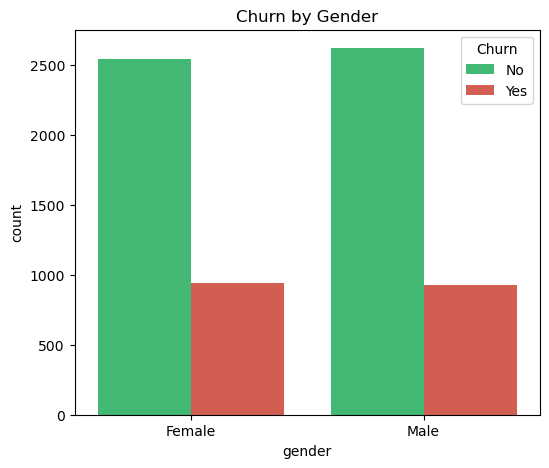

In [16]:
# ---- CHART 8: Churn by Gender ----
plt.figure(figsize=(6,5))
sns.countplot(x='gender', hue='Churn', data=df,
              palette=['#2ecc71','#e74c3c'])
plt.title('Churn by Gender')
plt.savefig(r'C:\Users\pradh\OneDrive\Desktop\churn_gender.png')
plt.show()

In [18]:
# Convert Yes/No columns to numbers
df_num = df.copy()
df_num['Churn'] = df_num['Churn'].map({'Yes': 1, 'No': 0})
df_num['gender'] = df_num['gender'].map({'Male': 1, 'Female': 0})
df_num['Partner'] = df_num['Partner'].map({'Yes': 1, 'No': 0})
df_num['Dependents'] = df_num['Dependents'].map({'Yes': 1, 'No': 0})
df_num['PhoneService'] = df_num['PhoneService'].map({'Yes': 1, 'No': 0})
df_num['PaperlessBilling'] = df_num['PaperlessBilling'].map({'Yes': 1, 'No': 0})

In [19]:
# Keep only numeric columns
numeric_cols = df_num.select_dtypes(include='number')

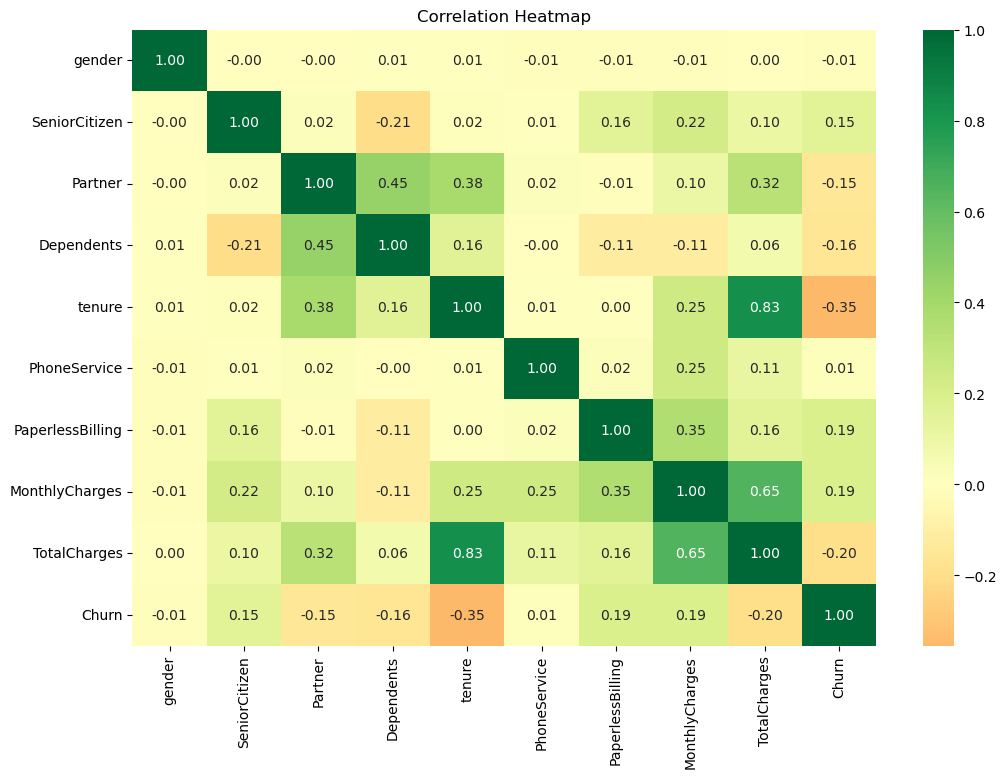

In [20]:
# Plot heatmap
plt.figure(figsize=(12,8))
sns.heatmap(numeric_cols.corr(), annot=True, fmt='.2f',
            cmap='RdYlGn', center=0)
plt.title('Correlation Heatmap')
plt.savefig(r'C:\Users\pradh\OneDrive\Desktop\churn_heatmap.png')
plt.show()

In [21]:
# Average tenure of churned vs retained
print("Average Tenure:")
print(df.groupby('Churn')['tenure'].mean().round(1))

Average Tenure:
Churn
No     37.7
Yes    18.0
Name: tenure, dtype: float64


In [22]:
# Churn % by contract type
print("\nChurn % by Contract Type:")
print(df.groupby('Contract')['Churn'].value_counts(normalize=True).unstack() * 100)


Churn % by Contract Type:
Churn                  No        Yes
Contract                            
Month-to-month  57.290323  42.709677
One year        88.722826  11.277174
Two year        97.151335   2.848665


In [23]:
# Average monthly charges
print("\nAverage Monthly Charges:")
print(df.groupby('Churn')['MonthlyCharges'].mean().round(2))


Average Monthly Charges:
Churn
No     61.31
Yes    74.44
Name: MonthlyCharges, dtype: float64


In [24]:
# Revenue lost to churn
churned = df[df['Churn']=='Yes']
print("\nTotal Monthly Revenue Lost to Churn:")
print(f"${churned['MonthlyCharges'].sum():,.2f}")

print("\nTotal Revenue Lost (All Time):")
print(f"${churned['TotalCharges'].sum():,.2f}")


Total Monthly Revenue Lost to Churn:
$139,130.85

Total Revenue Lost (All Time):
$2,862,926.90


In [25]:
# Final summary table
summary = pd.DataFrame({
    'Metric': [
        'Overall Churn Rate',
        'Month-to-Month Churn Rate',
        'Two-Year Contract Churn Rate',
        'Avg Monthly Charges (Churned)',
        'Avg Monthly Charges (Retained)',
        'Total Revenue Lost'
    ],
    'Value': [
        '26.6%',
        '42.7%',
        '2.8%',
        '$74.44',
        '$61.31',
        '$2,862,926.90'
    ]
})

print(summary.to_string(index=False))
summary.to_csv(r'C:\Users\pradh\OneDrive\Desktop\churn_summary.csv', index=False)
print("\nSummary saved!")

                        Metric         Value
            Overall Churn Rate         26.6%
     Month-to-Month Churn Rate         42.7%
  Two-Year Contract Churn Rate          2.8%
 Avg Monthly Charges (Churned)        $74.44
Avg Monthly Charges (Retained)        $61.31
            Total Revenue Lost $2,862,926.90

Summary saved!
